## Project Overview
This project focuses on analyzing and forecasting the closing price of Netflix stock using Python and the Prophet model. The notebook covers data loading, cleaning, model training, and generating future predictions


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### Data Loading and Initial Exploration
Loading the dataset and previewing the first rows to ensure everything is imported correctly.


In [2]:
data = pd.read_csv('C:/Users/athen/Downloads/Netflix Historical Data/HistoricalData_1744405684704.csv')

data.head()

,Date,Close/Last,Volume,Open,High,Low
0,04/10/2025,$921.17,5129755,$931.94,$941.235,$894.00
1,04/09/2025,$945.47,7497974,$855.93,$951.43,$854.40
2,04/08/2025,$870.40,5625382,$912.44,$922.42,$857.70
3,04/07/2025,$867.83,6656823,$827.845,$906.74,$821.10
4,04/04/2025,$855.86,6798806,$896.50,$906.6282,$853.87


### Data Cleaning
Conveting  date values to datetime format and cleaning  the closing price colum.


In [3]:
# Convert Date column
data['Date'] = pd.to_datetime(data['Date'])

# Clean price column
data['Close/Last'] = data['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

data.head()

,Date,Close/Last,Volume,Open,High,Low
0,2025-04-10,921.17,5129755,$931.94,$941.235,$894.00
1,2025-04-09,945.47,7497974,$855.93,$951.43,$854.40
2,2025-04-08,870.40,5625382,$912.44,$922.42,$857.70
3,2025-04-07,867.83,6656823,$827.845,$906.74,$821.10
4,2025-04-04,855.86,6798806,$896.50,$906.6282,$853.87


### Preparing Data for Prophet


In [4]:
df = data[['Date', 'Close/Last']].rename(columns={'Date': 'ds', 'Close/Last': 'y'})
df.head()


,ds,y
0,2025-04-10,921.17
1,2025-04-09,945.47
2,2025-04-08,870.40
3,2025-04-07,867.83
4,2025-04-04,855.86


### Training the Prophet Model
Initializing and fitting the model using the prepared time series.


In [5]:
model = Prophet()
model.fit(df)


13:49:24 - cmdstanpy - INFO - Chain [1] start processing
13:49:24 - cmdstanpy - INFO - Chain [1] done processing


### Creating Future Timeline
Generating future dates (30 days ahead) for forecasting.


In [6]:
future = model.make_future_dataframe(periods=30)
future.tail()


,ds
2541,2025-05-06
2542,2025-05-07
2543,2025-05-08
2544,2025-05-09
2545,2025-05-10


### Generating Forecast
Predicting future values and inspecting the results.


In [7]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
2541,2025-05-06,930.758373,885.155991,980.767542
2542,2025-05-07,931.916459,884.768350,978.728364
2543,2025-05-08,933.087865,888.826647,980.248474
2544,2025-05-09,933.340184,886.904590,979.377250
2545,2025-05-10,914.182529,867.157789,958.486580


### Forecast Plot
Visualizing the prediction results using Prophet’s built-in plotting utilities.


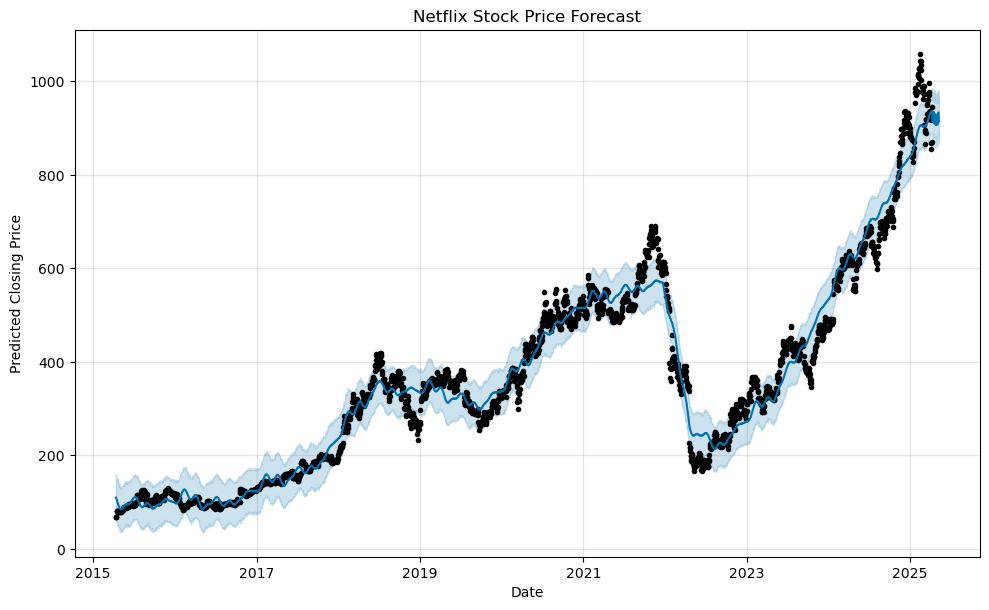

In [8]:
model.plot(forecast)
plt.title("Netflix Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Closing Price")
plt.show()


### Conclusion
This analysis demonstrates how time series forecasting can be applied to real financial data.  
Using Prophet, we generated a 30-day prediction for Netflix's closing stock prices, which can support trend analysis, decision-making, and further financial modeling.


### Trend Analysis
Netflix’s stock price shows a clear long-term upward trend, reflecting consistent market growth